# Hindsight: CUAD Commercial Legal CBA Experiment

## Concept Binding Accuracy on Commercial Contract Clauses

**Domain**: Commercial law (M&A due diligence contracts)  
**Dataset**: [CUAD](https://github.com/TheAtticusProject/cuad) — 510 contracts, 41 categories, 13K+ expert annotations (CC BY 4.0)  
**Task**: Classify extracted contract clause spans into confusable concept categories  

### Why CUAD?

CUAD has **1,210 shared spans** — identical text annotated with different categories. This is genuine
concept binding ambiguity: the same clause serves multiple legal purposes.

| Family | Concepts | Shared Spans | Why Confusable |
|--------|----------|-------------|----------------|
| Dates | Agreement Date, Effective Date, Expiration Date | 247 | Same date serves multiple temporal roles |
| License | License Grant, Non-Transferable License, Irrevocable/Perpetual License, Exclusivity | 194 | Same grant clause, different properties |
| Liability | Cap On Liability, Uncapped Liability, Liquidated Damages | 134 | Same paragraph caps AND carves out exceptions |
| Term | Termination For Convenience, Renewal Term, Notice Period To Terminate Renewal | 103 | One passage defines term, renewal, AND notice |
| Control | Change Of Control, Anti-Assignment | 31 | Both address transfer scenarios |

### Experiment Design

Same bundle approach as LEDGAR for direct comparison:
1. Extract annotated spans (with surrounding context for short spans like dates)
2. Bundle 15 spans (one per concept) into synthetic documents
3. LLM classifies each span → measure CBA

### Models
- Claude Haiku (claude-haiku-4-5-20251001)
- GPT-4o-mini

In [8]:
!pip install anthropic openai pandas -q

import anthropic, openai, json, time, os, random, re
from collections import defaultdict, Counter
from datetime import datetime
from google.colab import userdata


ANTHROPIC_API_KEY = userdata.get('ANTHROPIC_API_KEY')
OPENAI_API_KEY = userdata.get('OPENAI_API_KEY')

os.environ['ANTHROPIC_API_KEY'] = ANTHROPIC_API_KEY
os.environ['OPENAI_API_KEY'] = OPENAI_API_KEY

print("Setup complete.")

Setup complete.


In [9]:
# Cell 2: Load CUAD dataset and build span pools

CUAD_PATH = "/tmp/cuad_data/CUADv1.json"

# Ensure directory and download data if not exists
if not os.path.exists(CUAD_PATH):
      !mkdir -p /tmp/cuad_data && cd /tmp/cuad_data && curl -sL "https://raw.githubusercontent.com/TheAtticusProject/cuad/main/data.zip" -o data.zip && unzip -o data.zip

with open(CUAD_PATH) as f:
    cuad_data = json.load(f)['data']
print(f"CUAD loaded: {len(cuad_data)} contracts")


# 15 eval concepts in 5 confusable families
EVAL_CONCEPTS = [
    "Agreement Date", "Effective Date", "Expiration Date",
    "License Grant", "Non-Transferable License", "Irrevocable Or Perpetual License", "Exclusivity",
    "Cap On Liability", "Uncapped Liability", "Liquidated Damages",
    "Termination For Convenience", "Renewal Term", "Notice Period To Terminate Renewal",
    "Change Of Control", "Anti-Assignment",
]

MAX_SPAN_LENGTH = 1500  # Cap long spans
CONTEXT_WINDOW = 200    # Chars of context for short spans
SHORT_SPAN_THRESHOLD = 100  # Spans shorter than this get surrounding context

def build_clause_text(span_text, context_before, context_after, is_short):
    """Build the clause text with context for short spans."""
    if is_short and (context_before or context_after):
        # Include context for short spans (dates, brief phrases)
        parts = []
        if context_before:
            parts.append(f"...{context_before[-CONTEXT_WINDOW:]}")
        parts.append(f" >>>{span_text}<<< ")
        if context_after:
            parts.append(f"{context_after[:CONTEXT_WINDOW]}")
        return "".join(parts)
    else:
        # Long spans are self-contained
        text = span_text[:MAX_SPAN_LENGTH]
        if len(span_text) > MAX_SPAN_LENGTH:
            text += "..."
        return text

# Extract spans with context
span_pool = defaultdict(list)  # concept -> list of clause_text strings

for doc in cuad_data:
    for para in doc['paragraphs']:
        context = para['context']
        for qa in para['qas']:
            q = qa['question']
            cat = q.split('"')[1] if '"' in q else q.strip()
            if cat not in EVAL_CONCEPTS:
                continue
            for a in qa['answers']:
                if not a['text'].strip():
                    continue
                span_text = a['text'].strip()
                start = a['answer_start']
                end = start + len(a['text'])

                ctx_before = context[max(0, start-CONTEXT_WINDOW):start].strip()
                ctx_after = context[end:min(len(context), end+CONTEXT_WINDOW)].strip()

                is_short = len(span_text) < SHORT_SPAN_THRESHOLD
                clause_text = build_clause_text(span_text, ctx_before, ctx_after, is_short)

                span_pool[cat].append(clause_text)

print(f"\nSpan pool sizes:")
for concept in EVAL_CONCEPTS:
    texts = span_pool[concept]
    avg_len = sum(len(t) for t in texts) / len(texts) if texts else 0
    print(f"  {concept:<40} {len(texts):>5} spans  (avg {avg_len:.0f} chars)")
print(f"\nTotal: {sum(len(v) for v in span_pool.values())} spans")

CUAD loaded: 510 contracts

Span pool sizes:
  Agreement Date                             476 spans  (avg 375 chars)
  Effective Date                             447 spans  (avg 362 chars)
  Expiration Date                            467 spans  (avg 277 chars)
  License Grant                              777 spans  (avg 441 chars)
  Non-Transferable License                   298 spans  (avg 440 chars)
  Irrevocable Or Perpetual License           165 spans  (avg 557 chars)
  Exclusivity                                410 spans  (avg 381 chars)
  Cap On Liability                           672 spans  (avg 394 chars)
  Uncapped Liability                         167 spans  (avg 459 chars)
  Liquidated Damages                         121 spans  (avg 375 chars)
  Termination For Convenience                246 spans  (avg 296 chars)
  Renewal Term                               210 spans  (avg 326 chars)
  Notice Period To Terminate Renewal         122 spans  (avg 313 chars)
  Change Of Control

In [10]:
# Cell 3: Ontology & Prompts

CUAD_ONTOLOGY = {
    "families": {
        "dates": ["Agreement Date", "Effective Date", "Expiration Date"],
        "license": ["License Grant", "Non-Transferable License", "Irrevocable Or Perpetual License", "Exclusivity"],
        "liability": ["Cap On Liability", "Uncapped Liability", "Liquidated Damages"],
        "term": ["Termination For Convenience", "Renewal Term", "Notice Period To Terminate Renewal"],
        "control": ["Change Of Control", "Anti-Assignment"],
    }
}

# Build concept_to_family lookup
concept_to_family = {}
for family, concepts in CUAD_ONTOLOGY["families"].items():
    for c in concepts:
        concept_to_family[c] = family

ontology = {
    "families": CUAD_ONTOLOGY["families"],
    "concept_to_family": concept_to_family,
}

SYSTEM_PROMPT = """You are a legal contract clause classification system. Given a set of numbered clauses extracted from commercial contracts, classify each clause into exactly one of the following categories.

Categories:
- Agreement Date: The date the agreement was signed or made
- Effective Date: The date the agreement takes effect (may differ from signing date)
- Expiration Date: The date or conditions under which the agreement expires
- License Grant: Provisions granting a license to use IP, technology, or rights
- Non-Transferable License: Provisions restricting transfer or sublicensing of granted rights
- Irrevocable Or Perpetual License: Provisions granting irrevocable or perpetual license rights
- Exclusivity: Provisions granting exclusive rights or restricting competition
- Cap On Liability: Provisions limiting or capping a party's liability
- Uncapped Liability: Provisions carving out exceptions from liability caps (uncapped exposure)
- Liquidated Damages: Provisions specifying pre-determined damages for breach
- Termination For Convenience: Provisions allowing termination without cause
- Renewal Term: Provisions defining automatic renewal or extension terms
- Notice Period To Terminate Renewal: Provisions specifying notice required to prevent renewal
- Change Of Control: Provisions triggered by ownership changes or acquisitions
- Anti-Assignment: Provisions restricting assignment of the agreement

For short spans (e.g., dates), surrounding context is provided in the format:
  ...context before... >>>SPAN<<< ...context after...
Classify the highlighted >>>SPAN<<< text, using the context to determine its role.

Return a JSON array where each item has:
- "clause": the clause number (integer)
- "concept": the category name from the list above (exact string match)

Rules:
- Classify EVERY clause — do not skip any
- Each clause gets exactly one category
- Use the exact category names listed above
- For spans with >>>markers<<<, classify based on the highlighted text's role in context"""

print(f"Ontology: {len(CUAD_ONTOLOGY['families'])} families, {len(EVAL_CONCEPTS)} concepts")
print(f"System prompt: {len(SYSTEM_PROMPT)} chars")

Ontology: 5 families, 15 concepts
System prompt: 2005 chars


In [11]:
# Cell 4: Bundle Construction

N_BUNDLES = 50
random.seed(42)

# Shuffle span pools
shuffled_pools = {}
for concept in EVAL_CONCEPTS:
    pool = span_pool[concept].copy()
    random.shuffle(pool)
    shuffled_pools[concept] = pool

# Track usage index per concept
pool_idx = {c: 0 for c in EVAL_CONCEPTS}

bundles = []
for bundle_i in range(N_BUNDLES):
    clauses = []
    gt_mapping = {}  # clause_num -> concept

    for concept in EVAL_CONCEPTS:
        idx = pool_idx[concept] % len(shuffled_pools[concept])
        text = shuffled_pools[concept][idx]
        pool_idx[concept] += 1
        clauses.append((concept, text))

    # Shuffle within bundle
    random.shuffle(clauses)

    doc_parts = []
    for clause_num, (concept, text) in enumerate(clauses, 1):
        doc_parts.append(f"Clause {clause_num}:\n{text}")
        gt_mapping[clause_num] = concept

    bundle_text = "\n\n".join(doc_parts)

    bundles.append({
        "bundle_id": bundle_i,
        "text": bundle_text,
        "gt_mapping": gt_mapping,
        "n_clauses": len(clauses),
        "text_length": len(bundle_text),
    })

lengths = [b["text_length"] for b in bundles]
print(f"Created {len(bundles)} bundles")
print(f"Clauses per bundle: {bundles[0]['n_clauses']}")
print(f"Bundle text length: min={min(lengths)}, median={sorted(lengths)[len(lengths)//2]}, max={max(lengths)}")
print(f"Approx tokens per bundle: {sorted(lengths)[len(lengths)//2] // 4}")
print(f"Total classifications: {sum(b['n_clauses'] for b in bundles)}")

# Show sample
print(f"\n--- Sample bundle (first 3 clauses) ---")
sample = bundles[0]
for clause_num in range(1, 4):
    concept = sample['gt_mapping'][clause_num]
    # Find clause text
    clause_text = sample['text'].split(f"Clause {clause_num}:\n")[1].split(f"\n\nClause {clause_num+1}")[0] if clause_num < 15 else ""
    print(f"\n  Clause {clause_num} → GT: {concept}")
    print(f"  Text preview: {clause_text[:120]}...")

Created 50 bundles
Clauses per bundle: 15
Bundle text length: min=4078, median=6105, max=7897
Approx tokens per bundle: 1526
Total classifications: 750

--- Sample bundle (first 3 clauses) ---

  Clause 1 → GT: Irrevocable Or Perpetual License
  Text preview: Following expiration of the Royalty Term (as defined in the License Agreement) for any Licensed Product in a given count...

  Clause 2 → GT: Anti-Assignment
  Text preview: The rights and obligations created by this Agreement may not be assigned by Company, in whole or in part, without first ...

  Clause 3 → GT: Change Of Control
  Text preview: In the event of the merger or consolidation of Company with any other entity, Licensor shall have the right to terminate...


In [12]:
# Cell 5: Scoring Functions (same as LEDGAR for comparability)

def cba_strict(predicted_concept, ground_truth_concept):
    """Binary concept-binding accuracy: 1.0 if match, 0.0 otherwise."""
    return 1.0 if predicted_concept == ground_truth_concept else 0.0


def cba_soft(predicted_concept, ground_truth_concept, ontology):
    """Partial-credit CBA: 1.0 exact, 0.5 same family, 0.0 otherwise."""
    if predicted_concept == ground_truth_concept:
        return 1.0
    c2f = ontology.get("concept_to_family", {})
    gt_family = c2f.get(ground_truth_concept)
    pred_family = c2f.get(predicted_concept)
    if gt_family is not None and gt_family == pred_family:
        return 0.5
    return 0.0


def score_bundle(gt_mapping, pred_mapping, ontology):
    """Score a bundle of clause classifications."""
    per_field = []
    misbindings = []

    for clause_num, gt_concept in gt_mapping.items():
        pred_concept = pred_mapping.get(clause_num)

        if pred_concept is None:
            field_score = {
                "field_recall_contribution": 0.0,
                "cba_strict": 0.0,
                "cba_soft": 0.0,
                "is_misbinding": False,
                "gt_concept": gt_concept,
                "pred_concept": "__MISSING__",
                "clause_num": clause_num,
            }
        else:
            correct = (pred_concept == gt_concept)
            strict = 1.0 if correct else 0.0
            soft = cba_soft(pred_concept, gt_concept, ontology)

            field_score = {
                "field_recall_contribution": 1.0,
                "cba_strict": strict,
                "cba_soft": soft,
                "is_misbinding": not correct,
                "gt_concept": gt_concept,
                "pred_concept": pred_concept,
                "clause_num": clause_num,
            }

            if not correct:
                misbindings.append({
                    "gt_concept": gt_concept,
                    "pred_concept": pred_concept,
                    "clause_num": clause_num,
                })

        per_field.append(field_score)

    n = len(per_field)
    if n == 0:
        return {
            "field_recall": 0.0, "cba_strict": 0.0, "cba_soft": 0.0,
            "delta": 0.0, "n_fields": 0, "n_misbindings": 0,
            "misbindings": [], "per_field": [],
        }

    field_recall = sum(f["field_recall_contribution"] for f in per_field) / n
    cba_s = sum(f["cba_strict"] for f in per_field) / n
    cba_so = sum(f["cba_soft"] for f in per_field) / n

    return {
        "field_recall": round(field_recall, 6),
        "cba_strict": round(cba_s, 6),
        "cba_soft": round(cba_so, 6),
        "delta": round(field_recall - cba_s, 6),
        "n_fields": n,
        "n_misbindings": len(misbindings),
        "misbindings": misbindings,
        "per_field": per_field,
    }


def build_confusion_matrix(scored_bundles):
    """Build NxN concept confusion matrix."""
    concept_set = set(EVAL_CONCEPTS)
    pair_counts = defaultdict(int)

    for bundle in scored_bundles:
        for field in bundle.get("per_field", []):
            gt_c = field["gt_concept"]
            pred_c = field["pred_concept"]
            concept_set.add(gt_c)
            if pred_c != "__MISSING__":
                concept_set.add(pred_c)
            pair_counts[(gt_c, pred_c)] += 1

    concepts = sorted(concept_set)
    idx = {c: i for i, c in enumerate(concepts)}
    n = len(concepts)
    matrix = [[0] * n for _ in range(n)]
    for (gt_c, pred_c), count in pair_counts.items():
        if gt_c in idx and pred_c in idx:
            matrix[idx[gt_c]][idx[pred_c]] += count

    families = {c: concept_to_family.get(c, "unknown") for c in concepts}
    return {"matrix": matrix, "concepts": concepts, "families": families}


def top_confusions(matrix_data, n=15):
    """Return top N off-diagonal confusions."""
    concepts = matrix_data["concepts"]
    matrix = matrix_data["matrix"]
    confusions = []
    for i, gt_c in enumerate(concepts):
        for j, pred_c in enumerate(concepts):
            if i != j and matrix[i][j] > 0:
                confusions.append((gt_c, pred_c, matrix[i][j]))
    confusions.sort(key=lambda x: x[2], reverse=True)
    return confusions[:n]


# Sanity checks
test_gt = {1: "Agreement Date", 2: "Effective Date", 3: "Cap On Liability"}
test_pred = {1: "Effective Date", 2: "Agreement Date", 3: "Cap On Liability"}
test_result = score_bundle(test_gt, test_pred, ontology)
assert test_result["n_misbindings"] == 2
assert test_result["delta"] > 0
assert cba_soft("Agreement Date", "Effective Date", ontology) == 0.5
assert cba_soft("Agreement Date", "License Grant", ontology) == 0.0
print(f"Sanity check passed: F1={test_result['field_recall']}, CBA={test_result['cba_strict']:.3f}, "
      f"delta={test_result['delta']:.3f}, misbindings={test_result['n_misbindings']}")

Sanity check passed: F1=1.0, CBA=0.333, delta=0.667, misbindings=2


In [13]:
# Cell 6: LLM Call Functions

MAX_RETRIES = 5
BASE_DELAY = 2


def _parse_json(raw):
    """Strip markdown fences and parse JSON."""
    raw = raw.strip()
    if raw.startswith("```"):
        raw = raw.split("\n", 1)[1].rsplit("```", 1)[0]
    return json.loads(raw)


def _retry_with_backoff(fn, max_retries=MAX_RETRIES, base_delay=BASE_DELAY):
    """Call fn() with exponential backoff on rate-limit errors."""
    for attempt in range(max_retries):
        try:
            return fn()
        except Exception as e:
            is_rate_limit = "429" in str(e) or "rate_limit" in str(e).lower()
            if attempt < max_retries - 1:
                delay = base_delay * (2 ** attempt) if is_rate_limit else base_delay
                label = "Rate limited" if is_rate_limit else "Error"
                print(f"    {label}, retry {attempt+1}/{max_retries-1} in {delay}s: {type(e).__name__}")
                time.sleep(delay)
            else:
                raise


def _array_to_pred_mapping(stage2_array):
    """Convert LLM output array to {clause_num: concept} dict."""
    pred_mapping = {}
    for item in stage2_array:
        if not isinstance(item, dict):
            continue
        clause = item.get("clause") or item.get("clause_number") or item.get("provision")
        concept = item.get("concept", "")
        if clause is not None and concept:
            clause_num = int(clause)
            if clause_num not in pred_mapping:
                pred_mapping[clause_num] = concept
    return pred_mapping


def classify_anthropic(bundle_text, model):
    """Classify clauses using Anthropic API."""
    client = anthropic.Anthropic(api_key=ANTHROPIC_API_KEY)
    def _call():
        message = client.messages.create(
            model=model,
            max_tokens=1024,
            system=SYSTEM_PROMPT,
            messages=[{"role": "user", "content": f"Classify each clause below:\n\n{bundle_text}"}]
        )
        return _parse_json(message.content[0].text)
    return _retry_with_backoff(_call)


def classify_openai(bundle_text, model):
    """Classify clauses using OpenAI API."""
    client = openai.OpenAI(api_key=OPENAI_API_KEY)
    def _call():
        response = client.chat.completions.create(
            model=model,
            max_tokens=1024,
            messages=[
                {"role": "system", "content": SYSTEM_PROMPT},
                {"role": "user", "content": f"Classify each clause below:\n\n{bundle_text}"}
            ]
        )
        return _parse_json(response.choices[0].message.content)
    return _retry_with_backoff(_call)


def classify_bundle(bundle_text, model, provider):
    """Classify a bundle. Returns (raw_array, pred_mapping)."""
    if provider == "anthropic":
        raw_array = classify_anthropic(bundle_text, model)
    else:
        raw_array = classify_openai(bundle_text, model)
    pred_mapping = _array_to_pred_mapping(raw_array)
    return raw_array, pred_mapping


print("LLM call functions ready.")

LLM call functions ready.


In [14]:
# Cell 7: Run Loop

MODELS = {
    "haiku": {"provider": "anthropic", "model_id": "claude-haiku-4-5-20251001"},
    "gpt4o-mini": {"provider": "openai", "model_id": "gpt-4o-mini"},
}

RATE_DELAYS = {"anthropic": 2, "openai": 3}

experiments = {}

for model_name, model_cfg in MODELS.items():
    config_key = model_name
    print(f"\n{'='*60}")
    print(f"Running: {config_key} — {model_cfg['model_id']}")
    print(f"{'='*60}")

    provider = model_cfg["provider"]
    model_id = model_cfg["model_id"]
    rate_delay = RATE_DELAYS[provider]

    bundle_results = []
    all_misbindings = []
    errors = []
    raw_outputs = []

    for i, bundle in enumerate(bundles):
        bundle_id = f"bundle_{bundle['bundle_id']:03d}"

        try:
            raw_array, pred_mapping = classify_bundle(
                bundle["text"], model_id, provider
            )

            raw_outputs.append({
                "bundle_id": bundle_id,
                "n_predictions": len(pred_mapping),
                "raw_array": raw_array,
            })

            bundle_score = score_bundle(bundle["gt_mapping"], pred_mapping, ontology)
            bundle_score["bundle_id"] = bundle_id
            bundle_score["predictions"] = pred_mapping
            bundle_score["gt"] = bundle["gt_mapping"]
            bundle_results.append(bundle_score)

            for mb in bundle_score["misbindings"]:
                mb["bundle_id"] = bundle_id
                mb["model"] = model_name
                all_misbindings.append(mb)

        except Exception as e:
            print(f"  ERROR on {bundle_id}: {e}")
            errors.append({"bundle_id": bundle_id, "error": str(e)})

        if (i + 1) % 10 == 0:
            if bundle_results:
                avg_f1 = sum(d["field_recall"] for d in bundle_results) / len(bundle_results)
                avg_cba = sum(d["cba_strict"] for d in bundle_results) / len(bundle_results)
                avg_delta = sum(d["delta"] for d in bundle_results) / len(bundle_results)
                print(f"  [{i+1}/{len(bundles)}] F1={avg_f1:.3f}, CBA={avg_cba:.3f}, "
                      f"delta={avg_delta:.3f}, misbindings={len(all_misbindings)}")

        time.sleep(rate_delay)

    n_docs = len(bundle_results)
    if n_docs > 0:
        corpus_f1 = sum(d["field_recall"] for d in bundle_results) / n_docs
        corpus_cba_strict = sum(d["cba_strict"] for d in bundle_results) / n_docs
        corpus_cba_soft = sum(d["cba_soft"] for d in bundle_results) / n_docs
        corpus_delta = sum(d["delta"] for d in bundle_results) / n_docs
    else:
        corpus_f1 = corpus_cba_strict = corpus_cba_soft = corpus_delta = 0.0

    experiments[config_key] = {
        "model_id": model_id,
        "model_name": model_name,
        "provider": provider,
        "field_recall": round(corpus_f1, 6),
        "cba_strict": round(corpus_cba_strict, 6),
        "cba_soft": round(corpus_cba_soft, 6),
        "delta": round(corpus_delta, 6),
        "n_bundles": n_docs,
        "total_misbindings": len(all_misbindings),
        "misbinding_log": all_misbindings,
        "per_bundle": bundle_results,
        "errors": errors,
        "raw_outputs": raw_outputs,
    }

    print(f"\n  DONE: F1={corpus_f1:.4f}, CBA-strict={corpus_cba_strict:.4f}, "
          f"CBA-soft={corpus_cba_soft:.4f}, delta={corpus_delta:.4f}, "
          f"misbindings={len(all_misbindings)}, errors={len(errors)}")

print(f"\n\nAll experiments complete. {len(experiments)} models run.")


Running: haiku — claude-haiku-4-5-20251001
  [10/50] F1=1.000, CBA=0.740, delta=0.260, misbindings=39
  [20/50] F1=1.000, CBA=0.757, delta=0.243, misbindings=73
  [30/50] F1=1.000, CBA=0.762, delta=0.238, misbindings=107
  [40/50] F1=1.000, CBA=0.760, delta=0.240, misbindings=144
  [50/50] F1=1.000, CBA=0.756, delta=0.244, misbindings=183

  DONE: F1=1.0000, CBA-strict=0.7560, CBA-soft=0.8547, delta=0.2440, misbindings=183, errors=0

Running: gpt4o-mini — gpt-4o-mini
  [10/50] F1=1.000, CBA=0.653, delta=0.347, misbindings=52
  [20/50] F1=1.000, CBA=0.667, delta=0.333, misbindings=100
  [30/50] F1=1.000, CBA=0.671, delta=0.329, misbindings=148
  [40/50] F1=1.000, CBA=0.665, delta=0.335, misbindings=201
  [50/50] F1=1.000, CBA=0.665, delta=0.335, misbindings=251

  DONE: F1=1.0000, CBA-strict=0.6653, CBA-soft=0.7947, delta=0.3347, misbindings=251, errors=0


All experiments complete. 2 models run.


In [15]:
# Cell 8: Results Dashboard

import pandas as pd

# --- Cross-model comparison ---
print("=" * 80)
print("CROSS-MODEL COMPARISON")
print("=" * 80)

comparison_rows = []
for config_key, results in experiments.items():
    comparison_rows.append({
        "Model": results["model_name"],
        "Field Recall": f"{results['field_recall']:.4f}",
        "CBA-strict": f"{results['cba_strict']:.4f}",
        "CBA-soft": f"{results['cba_soft']:.4f}",
        "Delta": f"{results['delta']:.4f}",
        "Misbindings": results["total_misbindings"],
        "Errors": len(results["errors"]),
    })
df_comparison = pd.DataFrame(comparison_rows)
print(df_comparison.to_string(index=False))

# --- Per-concept accuracy ---
print(f"\n{'='*80}")
print("PER-CONCEPT ACCURACY")
print("=" * 80)

for config_key, results in experiments.items():
    print(f"\n--- {config_key} ---")
    concept_stats = defaultdict(lambda: {"field_acc": [], "cba_strict": [], "cba_soft": [], "misbindings": 0})

    for bundle in results["per_bundle"]:
        for field in bundle["per_field"]:
            gt_c = field["gt_concept"]
            if gt_c in EVAL_CONCEPTS:
                concept_stats[gt_c]["field_acc"].append(field["field_recall_contribution"])
                concept_stats[gt_c]["cba_strict"].append(field["cba_strict"])
                concept_stats[gt_c]["cba_soft"].append(field["cba_soft"])
                if field["is_misbinding"]:
                    concept_stats[gt_c]["misbindings"] += 1

    concept_rows = []
    for concept in EVAL_CONCEPTS:
        stats = concept_stats[concept]
        n = len(stats["field_acc"])
        if n > 0:
            fa = sum(stats["field_acc"]) / n
            cs = sum(stats["cba_strict"]) / n
            soft = sum(stats["cba_soft"]) / n
            delta = fa - cs
            concept_rows.append({
                "Concept": concept,
                "Family": concept_to_family.get(concept, "?"),
                "N": n,
                "F1": f"{fa:.3f}",
                "CBA": f"{cs:.3f}",
                "CBA-soft": f"{soft:.3f}",
                "Delta": f"{delta:.3f}",
                "Misbindings": stats["misbindings"],
            })
        else:
            concept_rows.append({
                "Concept": concept, "Family": concept_to_family.get(concept, "?"),
                "N": 0, "F1": "N/A", "CBA": "N/A", "CBA-soft": "N/A",
                "Delta": "N/A", "Misbindings": 0,
            })

    df_concepts = pd.DataFrame(concept_rows)
    print(df_concepts.to_string(index=False))

# --- Misbinding confusion pairs ---
print(f"\n{'='*80}")
print("MISBINDING CONFUSION PAIRS")
print("=" * 80)

for config_key, results in experiments.items():
    print(f"\n--- {config_key} ---")
    pair_counter = Counter()
    for mb in results["misbinding_log"]:
        pair_counter[(mb["gt_concept"], mb["pred_concept"])] += 1

    if pair_counter:
        pair_rows = []
        for (gt_c, pred_c), count in pair_counter.most_common(15):
            gt_fam = concept_to_family.get(gt_c, "unknown")
            pred_fam = concept_to_family.get(pred_c, "unknown")
            pair_rows.append({
                "GT Concept": gt_c,
                "Pred Concept": pred_c,
                "Count": count,
                "Same Family?": "Yes" if gt_fam == pred_fam else "No",
            })
        df_pairs = pd.DataFrame(pair_rows)
        print(df_pairs.to_string(index=False))
    else:
        print("  No misbindings detected.")

CROSS-MODEL COMPARISON
     Model Field F1 CBA-strict CBA-soft  Delta  Misbindings  Errors
     haiku   1.0000     0.7560   0.8547 0.2440          183       0
gpt4o-mini   1.0000     0.6653   0.7947 0.3347          251       0

PER-CONCEPT ACCURACY

--- haiku ---
                           Concept    Family  N    F1   CBA CBA-soft Delta  Misbindings
                    Agreement Date     dates 50 1.000 0.800    0.890 0.200           10
                    Effective Date     dates 50 1.000 0.760    0.880 0.240           12
                   Expiration Date     dates 50 1.000 0.660    0.770 0.340           17
                     License Grant   license 50 1.000 0.500    0.740 0.500           25
          Non-Transferable License   license 50 1.000 0.820    0.870 0.180            9
  Irrevocable Or Perpetual License   license 50 1.000 0.880    0.930 0.120            6
                       Exclusivity   license 50 1.000 0.760    0.880 0.240           12
                  Cap On Liabili


CONFUSION MATRIX — haiku


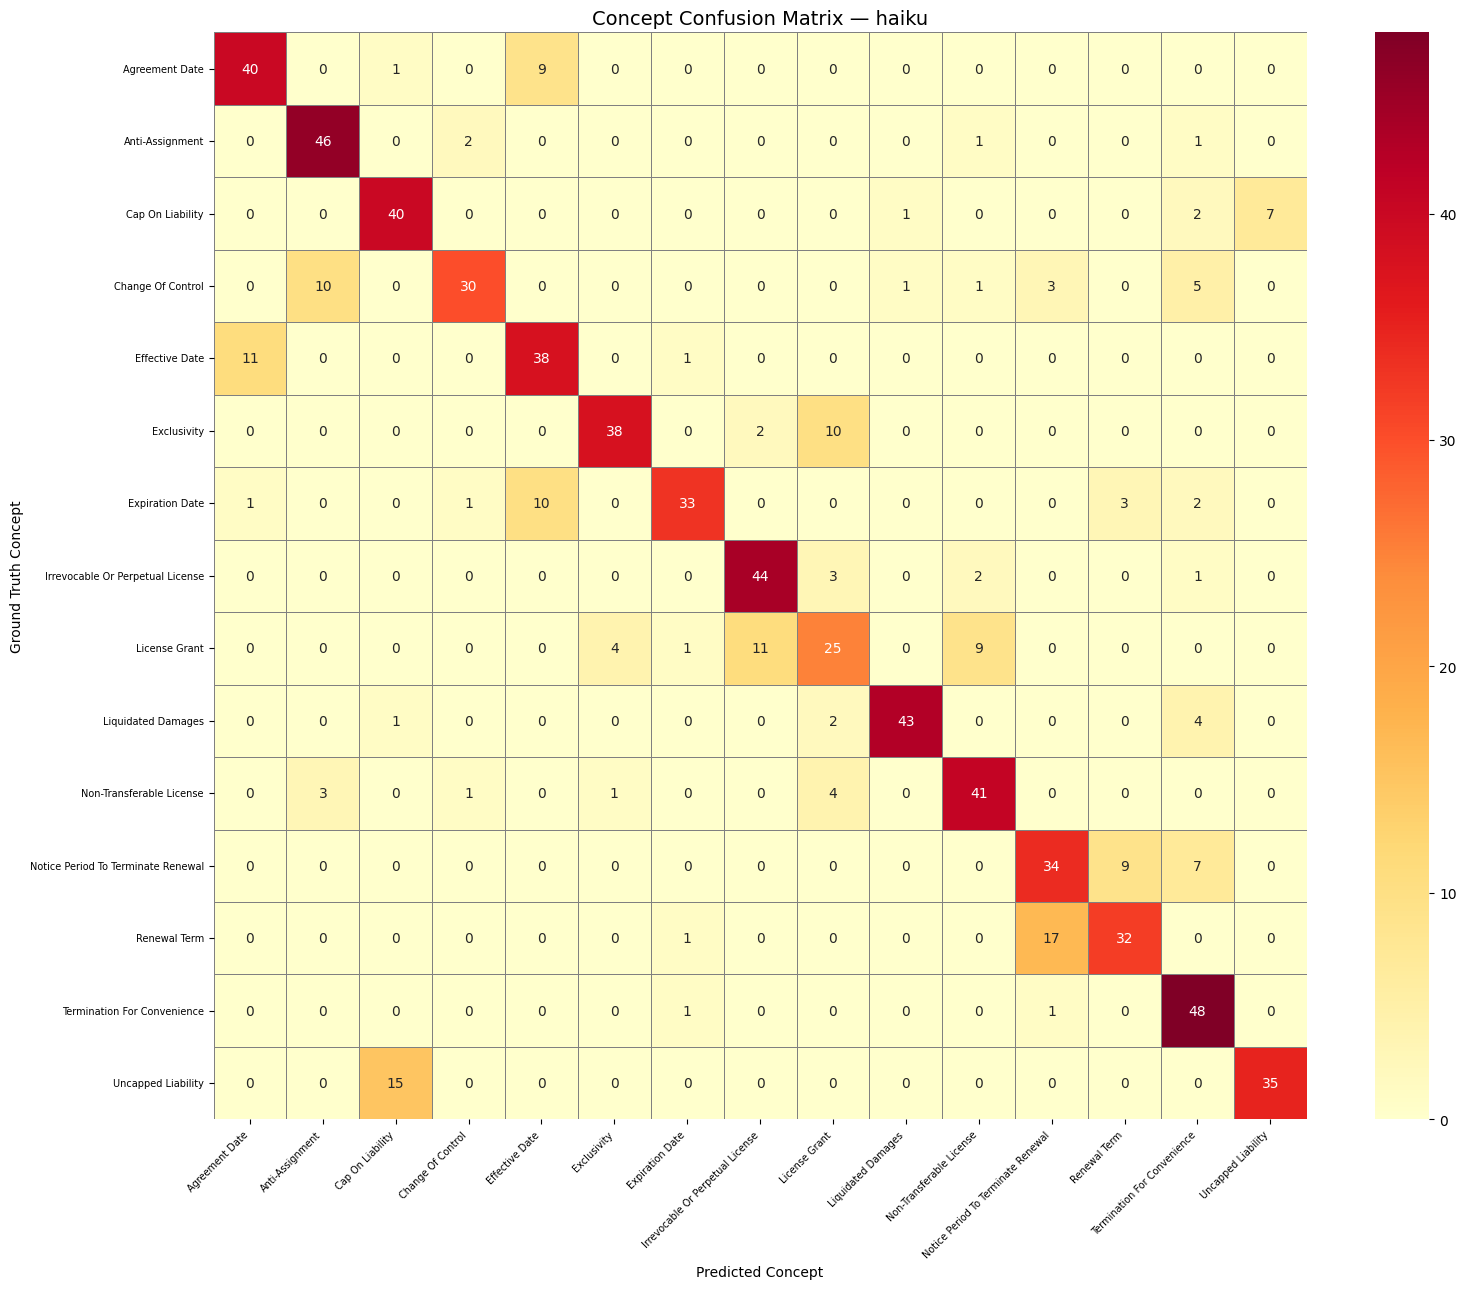


Top confusions (haiku):
                        GT Concept                       Pred Concept  Count Same Family?
                      Renewal Term Notice Period To Terminate Renewal     17          Yes
                Uncapped Liability                   Cap On Liability     15          Yes
                    Effective Date                     Agreement Date     11          Yes
                     License Grant   Irrevocable Or Perpetual License     11          Yes
                 Change Of Control                    Anti-Assignment     10          Yes
                       Exclusivity                      License Grant     10          Yes
                   Expiration Date                     Effective Date     10          Yes
                    Agreement Date                     Effective Date      9          Yes
                     License Grant           Non-Transferable License      9          Yes
Notice Period To Terminate Renewal                       Renewal Term      

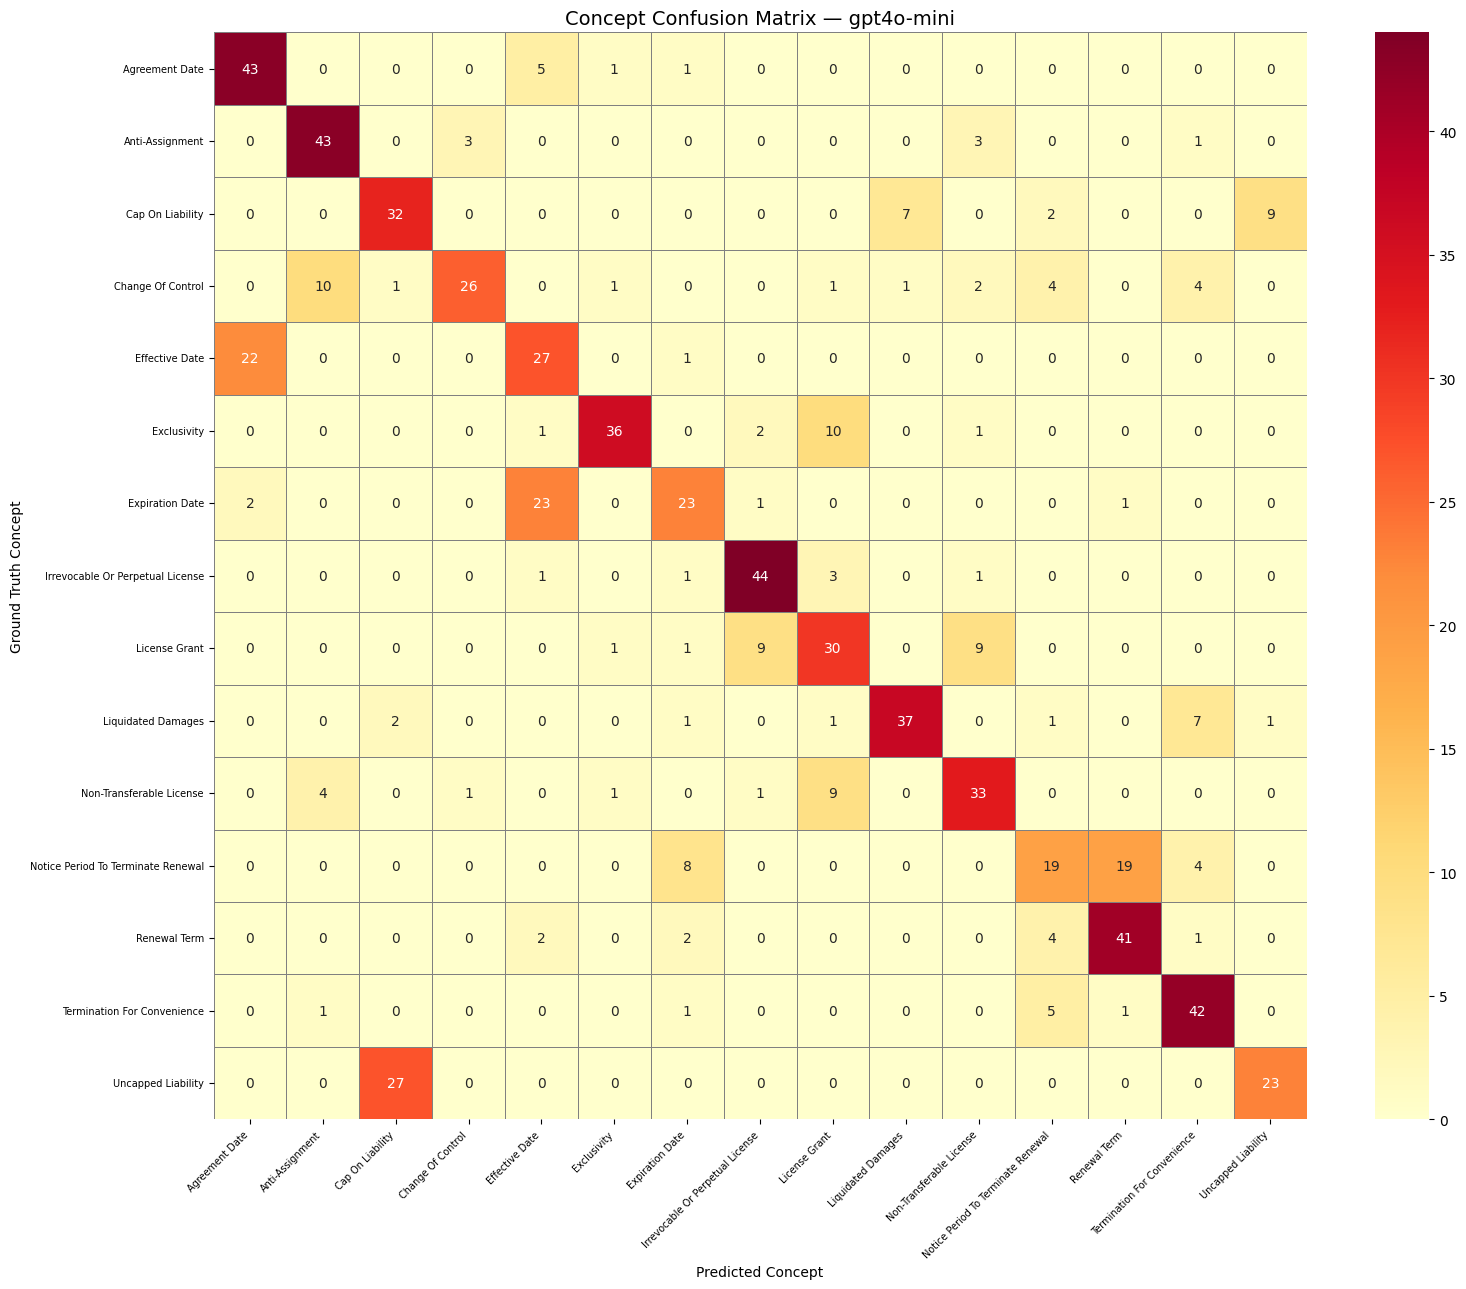


Top confusions (gpt4o-mini):
                        GT Concept                       Pred Concept  Count Same Family?
                Uncapped Liability                   Cap On Liability     27          Yes
                   Expiration Date                     Effective Date     23          Yes
                    Effective Date                     Agreement Date     22          Yes
Notice Period To Terminate Renewal                       Renewal Term     19          Yes
                 Change Of Control                    Anti-Assignment     10          Yes
                       Exclusivity                      License Grant     10          Yes
                  Cap On Liability                 Uncapped Liability      9          Yes
                     License Grant   Irrevocable Or Perpetual License      9          Yes
                     License Grant           Non-Transferable License      9          Yes
          Non-Transferable License                      License Grant 

In [16]:
# Cell 9: Confusion Matrix

import numpy as np

try:
    import matplotlib.pyplot as plt
    import seaborn as sns
    HAS_PLOT = True
except ImportError:
    HAS_PLOT = False

for config_key, results in experiments.items():
    print(f"\n{'='*60}")
    print(f"CONFUSION MATRIX — {config_key}")
    print(f"{'='*60}")

    scored_bundles = results["per_bundle"]
    cm_data = build_confusion_matrix(scored_bundles)

    eval_idx = [i for i, c in enumerate(cm_data["concepts"]) if c in EVAL_CONCEPTS]
    eval_concepts_sorted = [cm_data["concepts"][i] for i in eval_idx]
    matrix_np = np.array(cm_data["matrix"])
    filtered_matrix = matrix_np[np.ix_(eval_idx, eval_idx)]

    df_cm = pd.DataFrame(
        filtered_matrix,
        index=eval_concepts_sorted,
        columns=eval_concepts_sorted
    )

    if HAS_PLOT:
        fig, ax = plt.subplots(figsize=(16, 13))
        sns.heatmap(
            df_cm, annot=True, fmt="d", cmap="YlOrRd", ax=ax,
            linewidths=0.5, linecolor="gray",
            xticklabels=True, yticklabels=True,
        )
        ax.set_title(f"Concept Confusion Matrix — {config_key}", fontsize=14)
        ax.set_xlabel("Predicted Concept")
        ax.set_ylabel("Ground Truth Concept")
        plt.xticks(rotation=45, ha="right", fontsize=7)
        plt.yticks(fontsize=7)
        plt.tight_layout()
        plt.show()
    else:
        print(df_cm.to_string())

    print(f"\nTop confusions ({config_key}):")
    top = top_confusions(cm_data, n=15)
    if top:
        top_rows = []
        for gt_c, pred_c, count in top:
            gt_fam = concept_to_family.get(gt_c, "unknown")
            pred_fam = concept_to_family.get(pred_c, "unknown")
            top_rows.append({
                "GT Concept": gt_c,
                "Pred Concept": pred_c,
                "Count": count,
                "Same Family?": "Yes" if gt_fam == pred_fam else "No",
            })
        df_top = pd.DataFrame(top_rows)
        print(df_top.to_string(index=False))

# --- Expected confusion pairs ---
print(f"\n{'='*60}")
print("EXPECTED CONFUSION PAIRS — Cross-model summary")
print(f"{'='*60}")

expected_pairs = [
    ("Agreement Date", "Effective Date"),
    ("Effective Date", "Agreement Date"),
    ("Effective Date", "Expiration Date"),
    ("Expiration Date", "Renewal Term"),
    ("Cap On Liability", "Uncapped Liability"),
    ("Uncapped Liability", "Cap On Liability"),
    ("License Grant", "Non-Transferable License"),
    ("License Grant", "Exclusivity"),
    ("Non-Transferable License", "License Grant"),
    ("Irrevocable Or Perpetual License", "License Grant"),
    ("Exclusivity", "License Grant"),
    ("Renewal Term", "Notice Period To Terminate Renewal"),
    ("Notice Period To Terminate Renewal", "Renewal Term"),
    ("Change Of Control", "Anti-Assignment"),
    ("Anti-Assignment", "Change Of Control"),
    ("Termination For Convenience", "Renewal Term"),
]

pair_summary_rows = []
for gt_c, pred_c in expected_pairs:
    row = {"GT": gt_c, "Pred": pred_c}
    for config_key, results in experiments.items():
        count = sum(1 for mb in results["misbinding_log"]
                    if mb["gt_concept"] == gt_c and mb["pred_concept"] == pred_c)
        row[config_key] = count
    pair_summary_rows.append(row)

df_expected = pd.DataFrame(pair_summary_rows)
print(df_expected.to_string(index=False))

In [17]:
# Cell 10: Export

RESULTS_DIR = os.path.join(os.path.dirname(os.path.abspath("__file__")), "..", "results")
os.makedirs(RESULTS_DIR, exist_ok=True)

all_misbinding_log = []
for config_key, results in experiments.items():
    all_misbinding_log.extend(results["misbinding_log"])

all_scored_bundles = []
for config_key, results in experiments.items():
    all_scored_bundles.extend(results["per_bundle"])
combined_cm = build_confusion_matrix(all_scored_bundles)

export_results = {
    "experiment": "hindsight_cuad_cba",
    "dataset": "CUAD v1 (TheAtticusProject/cuad)",
    "domain": "commercial_law",
    "scoring": "direct_classification_cba",
    "date": datetime.now().strftime("%Y-%m-%d"),
    "description": (
        "Commercial law concept binding on CUAD contract clauses. "
        "Bundles of 15 spans from confusable families. "
        "Short spans (dates) include surrounding context with >>>markers<<<. "
        "LLM classifies each span; CBA measures binding accuracy."
    ),
    "n_bundles": len(bundles),
    "clauses_per_bundle": bundles[0]["n_clauses"],
    "total_classifications": sum(b["n_clauses"] for b in bundles),
    "eval_concepts": EVAL_CONCEPTS,
    "ontology": CUAD_ONTOLOGY,
    "models": {
        model_name: {"model_id": cfg["model_id"], "provider": cfg["provider"]}
        for model_name, cfg in MODELS.items()
    },
    "results": {
        config_key: {
            "model": results["model_name"],
            "field_recall": results["field_recall"],
            "cba_strict": results["cba_strict"],
            "cba_soft": results["cba_soft"],
            "delta": results["delta"],
            "n_bundles": results["n_bundles"],
            "total_misbindings": results["total_misbindings"],
            "errors": len(results["errors"]),
            "per_bundle_summary": [
                {
                    "bundle_id": d["bundle_id"],
                    "field_recall": d["field_recall"],
                    "cba_strict": d["cba_strict"],
                    "cba_soft": d["cba_soft"],
                    "delta": d["delta"],
                    "n_misbindings": d["n_misbindings"],
                    "predictions": {str(k): v for k, v in d["predictions"].items()},
                    "gt": {str(k): v for k, v in d["gt"].items()},
                }
                for d in results["per_bundle"]
            ],
        }
        for config_key, results in experiments.items()
    },
    "raw_output_samples": {
        config_key: results["raw_outputs"][:5]
        for config_key, results in experiments.items()
    },
    "misbinding_log": all_misbinding_log,
    "confusion_matrix": {
        "concepts": combined_cm["concepts"],
        "matrix": combined_cm["matrix"],
        "families": combined_cm["families"],
    },
}

output_path = os.path.join(RESULTS_DIR, "hindsight_cuad_cba_results.json")
with open(output_path, "w", encoding="utf-8") as f:
    json.dump(export_results, f, indent=2, default=str)

print(f"Results exported to: {output_path}")
print(f"File size: {os.path.getsize(output_path) / 1024:.1f} KB")

# Final summary
print(f"\n{'='*70}")
print("EXPERIMENT SUMMARY — CUAD CBA (Commercial Law)")
print(f"{'='*70}")
print(f"Dataset: CUAD v1 (510 commercial contracts, 41 categories)")
print(f"Bundles: {len(bundles)} x {bundles[0]['n_clauses']} clauses = {sum(b['n_clauses'] for b in bundles)} total")
print(f"Concepts: {len(EVAL_CONCEPTS)} in {len(CUAD_ONTOLOGY['families'])} families")

for config_key, results in experiments.items():
    print(f"\n{config_key}:")
    print(f"  Field Recall:       {results['field_recall']:.4f}")
    print(f"  CBA-strict:     {results['cba_strict']:.4f}")
    print(f"  CBA-soft:       {results['cba_soft']:.4f}")
    print(f"  Delta (F1-CBA): {results['delta']:.4f}")
    print(f"  Misbindings:    {results['total_misbindings']}")

total_misbindings = sum(r["total_misbindings"] for r in experiments.values())
print(f"\nTotal misbindings across all models: {total_misbindings}")

# Cross-domain comparison
print(f"\n{'='*70}")
print("CROSS-DOMAIN COMPARISON (all experiments)")
print(f"{'='*70}")
print(f"{'Domain':<20} {'Delta Direction':<18} {'Interpretation'}")
print("-" * 70)
print(f"{'Paystubs':<20} {'~0':<18} {'Few confusable concepts'}")
print(f"{'CORD (Receipts)':<20} {'Negative':<18} {'Value extraction errors dominate'}")
print(f"{'LEDGAR (Employment)':<20} {'Positive':<18} {'Concept binding errors dominate'}")
for config_key, results in experiments.items():
    direction = 'Positive' if results['delta'] > 0.01 else ('Negative' if results['delta'] < -0.01 else '~0')
    print(f"{'CUAD (Commercial)':<20} {direction:<18} {'delta=' + f'{results["delta"]:.3f}'} ({config_key})")

Results exported to: /content/../results/hindsight_cuad_cba_results.json
File size: 243.3 KB

EXPERIMENT SUMMARY — CUAD CBA (Commercial Law)
Dataset: CUAD v1 (510 commercial contracts, 41 categories)
Bundles: 50 x 15 clauses = 750 total
Concepts: 15 in 5 families

haiku:
  Field F1:       1.0000
  CBA-strict:     0.7560
  CBA-soft:       0.8547
  Delta (F1-CBA): 0.2440
  Misbindings:    183

gpt4o-mini:
  Field F1:       1.0000
  CBA-strict:     0.6653
  CBA-soft:       0.7947
  Delta (F1-CBA): 0.3347
  Misbindings:    251

Total misbindings across all models: 434

CROSS-DOMAIN COMPARISON (all experiments)
Domain               Delta Direction    Interpretation
----------------------------------------------------------------------
Paystubs             ~0                 Few confusable concepts
CORD (Receipts)      Negative           Value extraction errors dominate
LEDGAR (Employment)  Positive           Concept binding errors dominate
CUAD (Commercial)    Positive           delta=0.244